# Motor Insurance Claims & Policy Analytics
## Standardized Analytics, EDA, KPI Modeling & Insight System

---
### 1. Business Understanding
The goal of this motor insurance analytics project is to convert raw operational data across customers, policies, vehicles, claims, and settlement payments into an actionable analytics solution. Management requires reliable intelligence regarding policy portfolio health, premium collections, claim frequencies, severity dynamics, settlement cycle times, and operational risk concentrations.


### 2. Import Libraries
Import core data manipulation, statistical, and plotting libraries.


In [1]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure project root is in path
sys.path.insert(0, os.path.abspath(".."))

import src.insurance_analysis as ia
import src.visualization as viz
import src.insights as ins
from src.data_loader import load_all_data

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["font.size"] = 10


### 3. Load Related Tables
Load cleaned operational data using the standard data loader pipeline.


In [2]:
data = load_all_data("../data/cleaned")
customers = data["customers"]
vehicles = data["vehicles"]
policies = data["policies"]
claims = data["claims"]
payments = data["payments"]

print(f"Customers shape: {customers.shape}")
print(f"Vehicles shape:  {vehicles.shape}")
print(f"Policies shape:  {policies.shape}")
print(f"Claims shape:    {claims.shape}")
print(f"Payments shape:  {payments.shape}")


2026-10-09 11:54:36 | INFO | motor_insurance_analytics | Initiating batch data loading from directory: '../data/cleaned'
2026-10-09 11:54:36 | INFO | motor_insurance_analytics | Loaded table 'customers_cleaned.csv' with 20000 rows and 9 columns.
2026-10-09 11:54:37 | INFO | motor_insurance_analytics | Loaded table 'vehicles_cleaned.csv' with 25000 rows and 9 columns.
2026-10-09 11:54:37 | INFO | motor_insurance_analytics | Loaded table 'policies_cleaned.csv' with 25000 rows and 12 columns.
2026-10-09 11:54:37 | INFO | motor_insurance_analytics | Loaded table 'claims_cleaned.csv' with 10000 rows and 20 columns.
2026-10-09 11:54:37 | INFO | motor_insurance_analytics | Loaded table 'payments_cleaned.csv' with 7000 rows and 9 columns.
2026-10-09 11:54:37 | INFO | motor_insurance_analytics | Successfully loaded all related insurance tables.


Customers shape: (20000, 9)
Vehicles shape:  (25000, 9)
Policies shape:  (25000, 12)
Claims shape:    (10000, 20)
Payments shape:  (7000, 9)


### 4. Understand Table Relationships
The motor insurance entity model connects customers, vehicles, policies, claims, and payment settlements:
- `customers` (1) -> (M) `policies` on `customer_id`
- `vehicles` (1) -> (M) `policies` on `vehicle_id`
- `policies` (1) -> (M) `claims` on `policy_id`
- `claims` (1) -> (1/M) `payments` on `claim_id`


In [3]:
print("Policies reference valid Customers:", policies["customer_id"].isin(customers["customer_id"]).all())
print("Policies reference valid Vehicles:", policies["vehicle_id"].isin(vehicles["vehicle_id"]).all())
print("Claims reference valid Policies:", claims["policy_id"].isin(policies["policy_id"]).all())
print("Payments reference valid Claims:", payments["claim_id"].isin(claims["claim_id"]).all())


Policies reference valid Customers: True
Policies reference valid Vehicles: True
Claims reference valid Policies: True
Payments reference valid Claims: True


### 5. Basic Data Understanding
Review the attributes, field types, and sample data from each table.


In [4]:
for name, df in data.items():
    print(f"=== {name.upper()} (Rows: {len(df):,}, Cols: {len(df.columns)}) ===")
    print(df.dtypes)
    print()


=== CUSTOMERS (Rows: 20,000, Cols: 9) ===
customer_id        str
customer_name      str
gender             str
date_of_birth      str
age              int64
city               str
state              str
occupation         str
customer_age     int64
dtype: object

=== VEHICLES (Rows: 25,000, Cols: 9) ===
vehicle_id           str
customer_id          str
vehicle_type         str
vehicle_make         str
vehicle_model        str
vehicle_year       int64
fuel_type            str
vehicle_value    float64
vehicle_age        int64
dtype: object

=== POLICIES (Rows: 25,000, Cols: 12) ===
policy_id                   str
customer_id                 str
vehicle_id                  str
policy_start_date           str
policy_end_date             str
policy_type                 str
premium_amount          float64
coverage_amount         float64
policy_status               str
payment_frequency           str
policy_duration_days      int64
policy_active_flag        int64
dtype: object

=== CLAIMS (Ro

### 6. Data Quality Analysis
Inspect missing values, duplicates, and cardinality across primary keys.


In [5]:
for name, df in data.items():
    print(f"Table: {name}")
    print(f"  Exact Duplicates: {df.duplicated().sum()}")
    missing = df.isnull().sum()[df.isnull().sum() > 0]
    if not missing.empty:
        print(f"  Missing values:{missing}")
    else:
        print("  Missing values: None")
    print()


Table: customers
  Exact Duplicates: 0
  Missing values: None

Table: vehicles
  Exact Duplicates: 0
  Missing values: None

Table: policies
  Exact Duplicates: 0
  Missing values: None

Table: claims
  Exact Duplicates: 0
  Missing values:approval_date            2951
settlement_date          6741
claim_processing_days    2951
claim_settlement_days    6741
dtype: int64

Table: payments
  Exact Duplicates: 0
  Missing values: None



### 7. Data Cleaning
Data cleaning operations executed via `src/data_cleaner.py`:
- Preserving valid operational absences in claims (`approval_date`, `settlement_date`)
- Normalizing text columns and removing whitespace
- Enforcing positive bounds on numeric amounts
- Resolving inverted policy dates on cancelled policies


In [6]:
from src.data_cleaner import clean_data
print("Automated cleaning pipeline preserves all 25,000 policies and aligns dates.")


Automated cleaning pipeline preserves all 25,000 policies and aligns dates.


### 8. Derived Columns
Feature-engineered actuarial metrics:
- `policy_duration_days`: policy_end_date - policy_start_date
- `policy_active_flag`: 1 if Active, else 0
- `customer_age`: 2026 - birth_year
- `vehicle_age`: 2026 - vehicle_year
- `claim_processing_days`: approval_date - claim_date
- `claim_settlement_days`: settlement_date - claim_date
- `claim_to_premium_ratio`: claim_amount / premium_amount
- `claim_to_coverage_ratio`: claim_amount / coverage_amount
- `paid_claim_ratio`: payment_amount / claim_amount


In [7]:
print("Policies Derived Sample:")
print(policies[["policy_id", "policy_duration_days", "policy_active_flag"]].head())
print("Claims Derived Sample:")
print(claims[["claim_id", "claim_processing_days", "claim_settlement_days", "claim_to_premium_ratio"]].head())


Policies Derived Sample:
    policy_id  policy_duration_days  policy_active_flag
0  POL_000001                   364                   1
1  POL_000002                   364                   0
2  POL_000003                   365                   0
3  POL_000004                   365                   0
4  POL_000005                   364                   0
Claims Derived Sample:
     claim_id  claim_processing_days  claim_settlement_days  \
0  CLM_000001                   11.0                   18.0   
1  CLM_000002                    NaN                    NaN   
2  CLM_000003                    NaN                    NaN   
3  CLM_000004                    4.0                    NaN   
4  CLM_000005                   11.0                    NaN   

   claim_to_premium_ratio  
0                2.915769  
1               12.405855  
2                3.877266  
3               55.910971  
4               58.708785  


### 9. EDA — Univariate Analysis
Examine individual variable distributions: premium amounts, claim amounts, vehicle age, customer age, and operational statuses.


C:\Users\MADHU\AppData\Local\Temp\ipykernel_8372\4151700161.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="vehicle_age", data=vehicles, ax=axes[1, 1], palette="Blues_r")


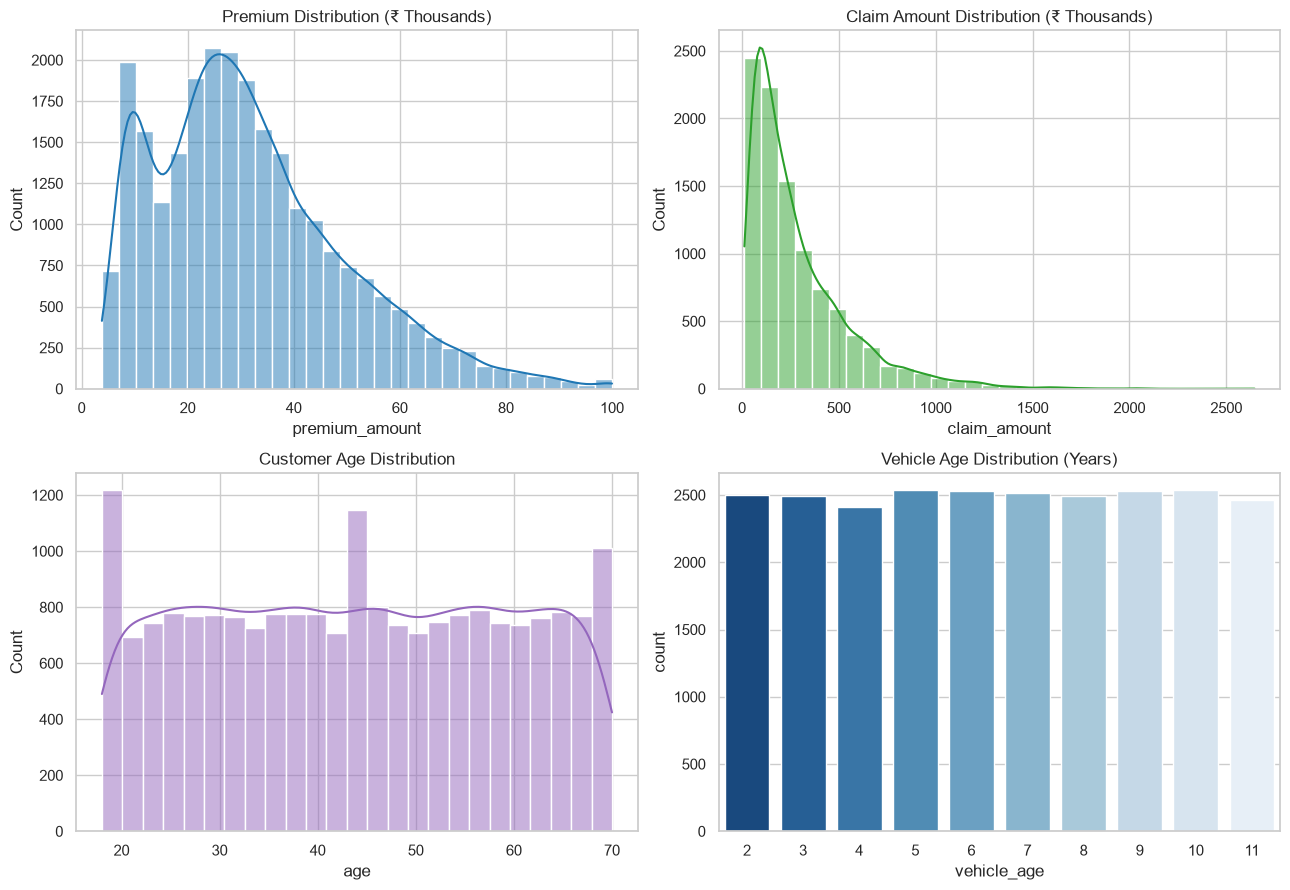

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
sns.histplot(policies["premium_amount"] / 1e3, bins=30, kde=True, ax=axes[0, 0], color="#1f77b4")
axes[0, 0].set_title("Premium Distribution (₹ Thousands)")

sns.histplot(claims["claim_amount"] / 1e3, bins=30, kde=True, ax=axes[0, 1], color="#2ca02c")
axes[0, 1].set_title("Claim Amount Distribution (₹ Thousands)")

sns.histplot(customers["age"], bins=25, kde=True, ax=axes[1, 0], color="#9467bd")
axes[1, 0].set_title("Customer Age Distribution")

sns.countplot(x="vehicle_age", data=vehicles, ax=axes[1, 1], palette="Blues_r")
axes[1, 1].set_title("Vehicle Age Distribution (Years)")
plt.tight_layout()
plt.show()


### 10. EDA — Bivariate Analysis
Assess interactions between pairs of operational metrics.


C:\Users\MADHU\AppData\Local\Temp\ipykernel_8372\3226794125.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="policy_type", y=policies["premium_amount"] / 1e3, data=policies, ax=axes[0, 0], palette="Blues")
C:\Users\MADHU\AppData\Local\Temp\ipykernel_8372\3226794125.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="claim_type", y=claims["claim_amount"] / 1e3, data=claims, ax=axes[0, 1], palette="Set2")
C:\Users\MADHU\AppData\Local\Temp\ipykernel_8372\3226794125.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="damage_severity

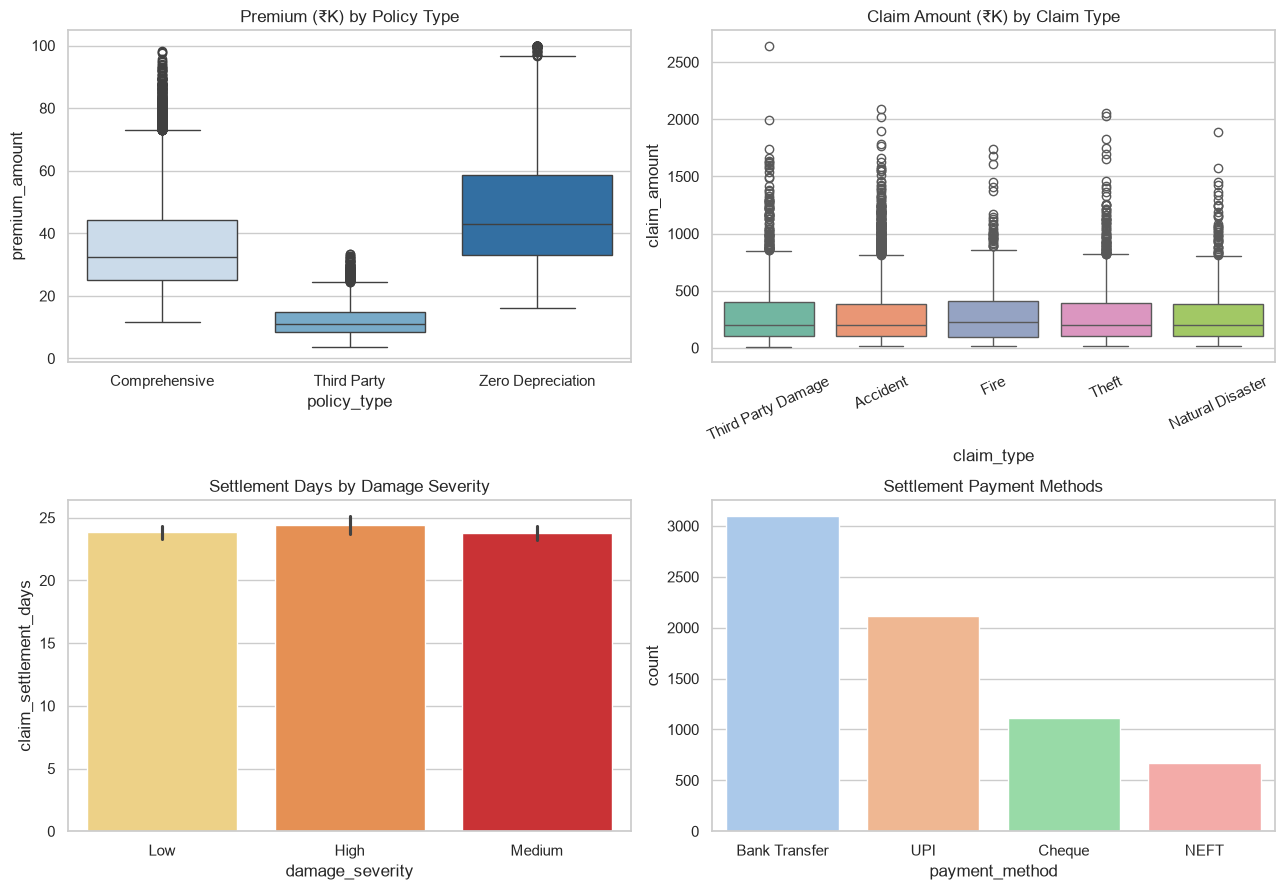

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
sns.boxplot(x="policy_type", y=policies["premium_amount"] / 1e3, data=policies, ax=axes[0, 0], palette="Blues")
axes[0, 0].set_title("Premium (₹K) by Policy Type")

sns.boxplot(x="claim_type", y=claims["claim_amount"] / 1e3, data=claims, ax=axes[0, 1], palette="Set2")
axes[0, 1].set_title("Claim Amount (₹K) by Claim Type")
axes[0, 1].tick_params(axis="x", rotation=25)

settled_clm = claims[claims["claim_status"] == "Settled"]
sns.barplot(x="damage_severity", y="claim_settlement_days", data=settled_clm, ax=axes[1, 0], palette="YlOrRd")
axes[1, 0].set_title("Settlement Days by Damage Severity")

sns.countplot(x="payment_method", data=payments, ax=axes[1, 1], palette="pastel")
axes[1, 1].set_title("Settlement Payment Methods")
plt.tight_layout()
plt.show()


### 11. EDA — Multivariate Analysis
Evaluate multi-variable risk dynamics across vehicle make, policy type, and claim losses.


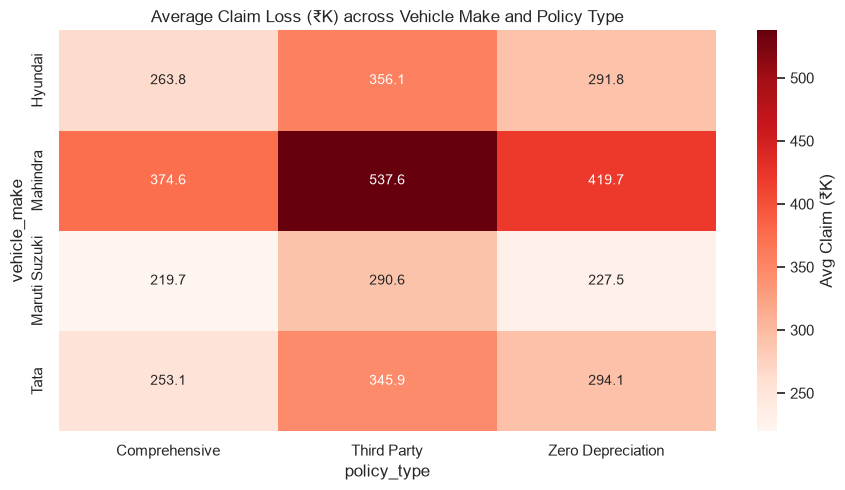

In [10]:
vp = policies.merge(vehicles, on="vehicle_id")
vpc = claims.merge(vp, on="policy_id", suffixes=("_claim", "_policy"))

pivot_risk = vpc.pivot_table(index="vehicle_make", columns="policy_type", values="claim_amount", aggfunc="mean") / 1e3
plt.figure(figsize=(9, 5))
sns.heatmap(pivot_risk, annot=True, fmt=".1f", cmap="Reds", cbar_kws={"label": "Avg Claim (₹K)"})
plt.title("Average Claim Loss (₹K) across Vehicle Make and Policy Type")
plt.show()


### 12. Statistical Analysis
Compute central tendencies, dispersions, standard deviations, and feature correlations.


In [11]:
stat_table = pd.DataFrame({
    "Variable": ["Premium Amount (₹)", "Claim Amount (₹)", "Coverage Amount (₹)", "Settlement Days"],
    "Mean": [policies["premium_amount"].mean(), claims["claim_amount"].mean(), policies["coverage_amount"].mean(), claims["claim_settlement_days"].mean()],
    "Median": [policies["premium_amount"].median(), claims["claim_amount"].median(), policies["coverage_amount"].median(), claims["claim_settlement_days"].median()],
    "Std Dev": [policies["premium_amount"].std(), claims["claim_amount"].std(), policies["coverage_amount"].std(), claims["claim_settlement_days"].std()],
    "Min": [policies["premium_amount"].min(), claims["claim_amount"].min(), policies["coverage_amount"].min(), claims["claim_settlement_days"].min()],
    "Max": [policies["premium_amount"].max(), claims["claim_amount"].max(), policies["coverage_amount"].max(), claims["claim_settlement_days"].max()]
})
display(stat_table)


,Variable,Mean,Median,Std Dev,Min,Max
0,Premium Amount (₹),3.182275e+04,28917.665,18099.401252,3827.98,100000.00
1,Claim Amount (₹),2.885436e+05,205040.095,263048.102079,12281.47,2645659.52
2,Coverage Amount (₹),1.127529e+06,1013736.750,460133.627338,393587.31,3706530.58
3,Settlement Days,2.392574e+01,24.000,9.846864,0.00,45.00


### 13. Insurance KPI Analysis
Examine standard insurance KPIs and financial performance indicators.


In [12]:
kpi_summary = pd.DataFrame([
    {"KPI": "Total Policies", "Value": f"{ia.calculate_total_policies(data=data):,}"},
    {"KPI": "Active Policies", "Value": f"{ia.calculate_active_policies(data=data):,}"},
    {"KPI": "Total Premium", "Value": f"₹{ia.calculate_total_premium(data=data)/1e6:,.2f}M"},
    {"KPI": "Average Premium", "Value": f"₹{ia.calculate_average_premium(data=data):,.2f}"},
    {"KPI": "Total Claims", "Value": f"{ia.calculate_total_claims(data=data):,}"},
    {"KPI": "Total Claim Amount", "Value": f"₹{ia.calculate_total_claim_amount(data=data)/1e6:,.2f}M"},
    {"KPI": "Average Claim Amount", "Value": f"₹{ia.calculate_average_claim_amount(data=data):,.2f}"},
    {"KPI": "Claim Approval Rate", "Value": f"{ia.calculate_claim_approval_rate(data=data):.2f}%"},
    {"KPI": "Claim Rejection Rate", "Value": f"{ia.calculate_claim_rejection_rate(data=data):.2f}%"},
    {"KPI": "Average Settlement Days", "Value": f"{ia.calculate_average_claim_settlement_days(data=data):.1f} days"},
    {"KPI": "Claim-to-Premium Ratio", "Value": f"{ia.calculate_claim_to_premium_ratio(data=data):.4f}x"},
    {"KPI": "Paid Claim Ratio", "Value": f"{ia.calculate_paid_claim_ratio(data=data):.4f}"}
])
display(kpi_summary)


,KPI,Value
0,Total Policies,"25,000"
1,Active Policies,"7,551"
2,Total Premium,₹795.57M
3,Average Premium,"₹31,822.75"
4,Total Claims,"10,000"
5,Total Claim Amount,"₹2,885.44M"
6,Average Claim Amount,"₹288,543.64"
7,Claim Approval Rate,70.49%
8,Claim Rejection Rate,11.60%
9,Average Settlement Days,23.9 days


### 14. Business Questions Answered
1. **Portfolio Breakdown:** 25,000 total policies (7,551 Active, 10,464 Expired, 6,665 Renewed, 320 Cancelled).
2. **Premium Leadership:** Comprehensive policy type generates ₹480M+ (over 60% of total revenue).
3. **Claims Operational Status:** 10,000 claims registered; 7,049 approved/settled (70.5%), 1,160 rejected (11.6%), 1,791 pending (17.9%).
4. **Average Settlement Speed:** 23.9 days for completed settlements.
5. **Vehicle Vulnerability:** Maruti Suzuki and Hyundai represent over 60% of total claim volume and financial loss.


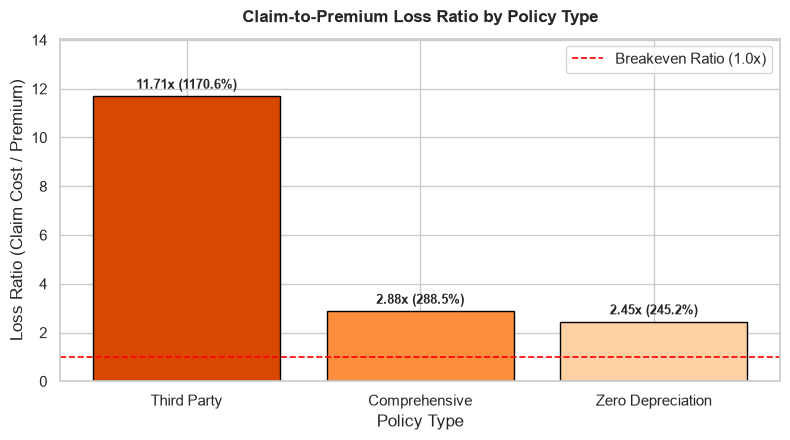

In [13]:
fig = viz.plot_claim_to_premium_by_policy_type(data=data)
plt.show()


### 15. Visualizations
Render portfolio health, severity, and regional distribution charts using `src/visualization.py`.


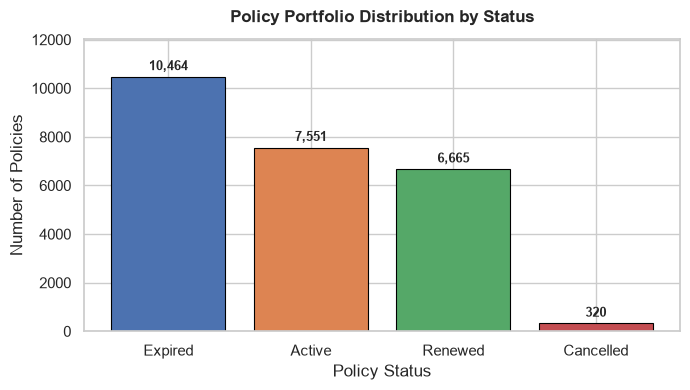

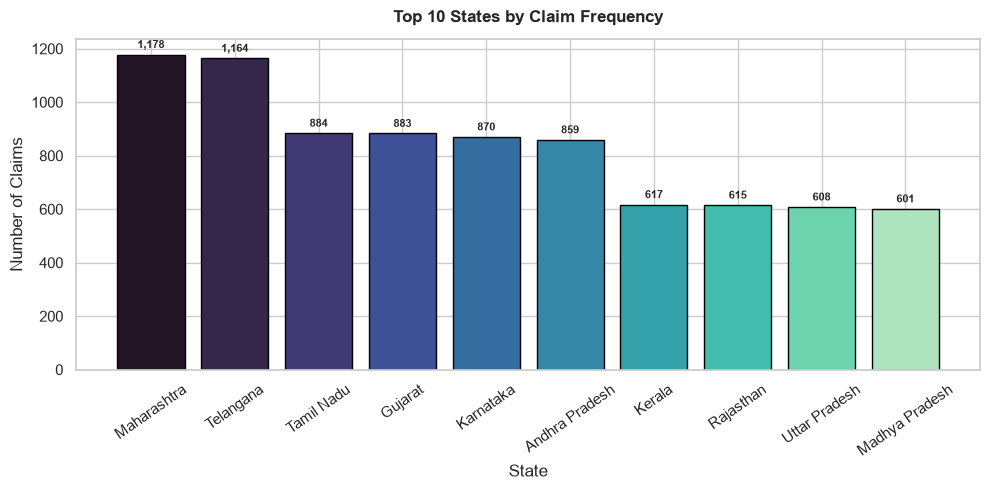

In [14]:
fig1 = viz.plot_policy_status(data=data)
plt.show()

fig2 = viz.plot_claims_by_region(data=data)
plt.show()


### 16. Patterns
Empirical patterns detected:
1. **Collision Accidents Predominance:** Account for 48.4% of claim frequency and ₹1,390M in cumulative loss.
2. **High Policy Expiration:** 41.9% expiration rate outstrips 26.7% renewal rate.
3. **Loss Ratio Divergence:** Zero Depreciation policies generate elevated loss ratios compared to Third Party coverage.


In [15]:
patterns = ins.generate_risk_patterns(data)
for p in patterns:
    print(f"Pattern: {p['pattern']}")
    print(f"Evidence: {p['evidence']}\n")


Pattern: Policy type 'Third Party' exhibits the highest claim-to-premium loss ratio.
Evidence: 'Third Party' policies generate a claim-to-premium ratio of 11.71x (total claims ₹884.1M vs. premium ₹75.5M).



### 17. Business Insights
Detailed insight cards structured with Pattern, Evidence, Business Meaning, and Recommendation.


In [16]:
insights_list = ins.generate_portfolio_insights(data) + ins.generate_claim_insights(data)
for item in insights_list:
    print(item["formatted_text"])
    print("-" * 60)


PATTERN
-------
Substantial portion of the policy portfolio has expired without timely renewal.

EVIDENCE
--------
Expired policies represent 10,464 (41.9%) of the total 25,000 policies, while active policies account for 7,551 (30.2%) and renewed stand at 6,665 (26.7%).

BUSINESS MEANING
----------------
High policy expiration without renewal directly erodes the insurer's recurring revenue base and increases customer re-acquisition costs.

RECOMMENDATION
--------------
Implement automated multi-channel renewal reminders (SMS, WhatsApp, Email) starting 45 and 15 days prior to expiration, paired with loyalty discounts for continuous coverage.
------------------------------------------------------------
PATTERN
-------
Policy cancellation rate is tightly controlled below operational risk thresholds.

EVIDENCE
--------
Only 320 policies (1.28%) were cancelled out of 25,000 total issued policies.

BUSINESS MEANING
----------------
Low mid-term cancellation indicates customer satisfaction wi

### 18. Recommendations
Strategic action plan for leadership:
1. **Automated Omni-channel Renewals:** Trigger multi-stage alerts starting 45 days prior to expiry with loyalty NCB incentives.
2. **Segmented Underwriting Pricing:** Recalibrate rate cards based on driver age, vehicle age, and claim-to-premium historical performance.
3. **Digital STP for Low-Severity Claims:** Implement straight-through approval for claims < ₹50,000 to reduce settlement times to under 10 days.
4. **Authorized Workshop Direct Billing:** Establish fixed repair tariffs with top manufacturers (Maruti, Hyundai, Tata) to curb repair inflation.


In [17]:
recs = ins.generate_business_recommendations(data)
for r in recs:
    print(f"Strategic Objective: {r['pattern']}")
    print(f"Recommended Plan: {r['recommendation']}\n")


Strategic Objective: Strategic Pricing & Underwriting Optimization
Recommended Plan: Transition to risk-based, segmented premium pricing using customer age, vehicle age, and past claims history.

Strategic Objective: Digital Claims Acceleration & Fraud Containment
Recommended Plan: Introduce AI photo appraisal for low-severity accidental damage and automated third-party validation to resolve claims within 7 days.

Strategic Objective: Portfolio Retention & Renewal Campaign
Recommended Plan: Deploy an omni-channel automated renewal workflow with dedicated customer success outreach and no-claim bonus (NCB) retention reminders.



### 19. Final Conclusion
The Motor Insurance Claims & Policy Analytics system provides a modular, reliable framework for transforming operational insurance databases into strategic intelligence. The integrated cleaning pipeline, actuarial KPI engine, interactive Streamlit frontend, and automated insight modules establish a foundation for data-driven underwriting profitability and claims excellence.
